Libraries imported successfully!

Loading SCRFD model...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 11

Saving 3253799-uhd_3840_2160_25fps.mp4 to 3253799-uhd_3840_2160_25fps.mp4
Video uploaded: 3253799-uhd_3840_2160_25fps.mp4

Video properties:
  FPS          : 25.0
  Total frames : 344
  Duration     : 13.76 seconds
  Resolution   : 3840 x 2160

Output video: output_face_detection.mp4

Processing video frames...
This may take a few minutes...
  Progress: 8.7% (30/344 frames)
  Progress: 17.4% (60/344 frames)
  Progress: 26.2% (90/344 frames)
  Progress: 34.9% (120/344 frames)
  Progress: 43.6% (150/344 frames)
  Progress: 52.3% (180/344 frames)
  Progress: 61.0% (210/344 frames)
  Progress: 69.8% (240/344 frames)
  Progress: 78.5% (270/344 frames)
  Progress: 87.2% (300/344 frames)
  Progress: 95.9% (330/344 frames)

Processing complete!
Total frames processed : 344
Total faces detected   : 436


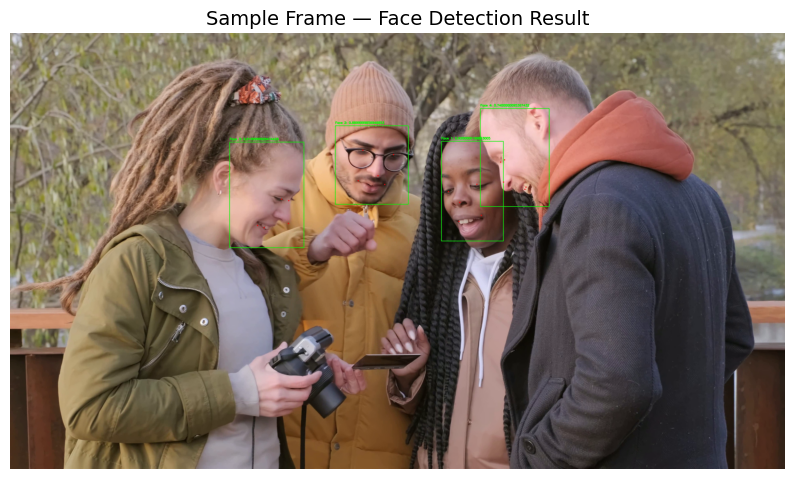

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Check your downloads folder.


In [4]:
# ============================================================
# Video Face Detection using SCRFD
# ============================================================
# Description  : Upload any video → detect faces in each
#                frame using pretrained SCRFD model →
#                save output video with bounding boxes
# Model        : SCRFD via InsightFace (buffalo_l)
# Author       : Fatima
# Project      : Bengali Celebrity Multimodal Dataset Pipeline
# ============================================================

# ── Step 1: Install Required Libraries ──────────────────────
!pip install insightface onnxruntime -q

# ── Step 2: Import Required Libraries ───────────────────────
import cv2                               # video processing
import numpy as np                       # numerical operations
import matplotlib.pyplot as plt          # displaying frames
from insightface.app import FaceAnalysis # pretrained SCRFD
from google.colab import files           # file upload/download

print("Libraries imported successfully!")

# ── Step 3: Load Pretrained SCRFD Model ─────────────────────
# buffalo_l = most accurate pretrained model
# trained on millions of faces → ready to use immediately
print("\nLoading SCRFD model...")
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))
print("SCRFD model loaded successfully!")

# ── Step 4: Upload Video ─────────────────────────────────────
# User uploads any video file from their computer
print("\nPlease upload a video file...")
uploaded = files.upload()

# get uploaded video filename automatically
video_filename = list(uploaded.keys())[0]
print(f"Video uploaded: {video_filename}")

# ── Step 5: Open Video and Get Properties ───────────────────
# cv2.VideoCapture opens video file for reading
cap = cv2.VideoCapture(video_filename)

# get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"\nVideo properties:")
print(f"  FPS          : {fps}")
print(f"  Total frames : {total_frames}")
print(f"  Duration     : {round(total_frames/fps, 2)} seconds")
print(f"  Resolution   : {width} x {height}")

# ── Step 6: Setup Output Video Writer ───────────────────────
# cv2.VideoWriter saves processed frames as output video
# mp4v = video codec for .mp4 format
output_filename = "output_face_detection.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_filename, fourcc, fps,
                      (width, height))

print(f"\nOutput video: {output_filename}")

# ── Step 7: Process Each Frame ──────────────────────────────
# For each frame in the video:
# → run SCRFD face detection
# → draw bounding boxes around detected faces
# → draw facial landmarks
# → write processed frame to output video

print("\nProcessing video frames...")
print("This may take a few minutes...")

frame_count = 0
total_faces_detected = 0

while True:
    # read one frame at a time from video
    ret, frame = cap.read()

    # if no more frames, stop
    if not ret:
        break

    # process every 3rd frame for speed
    # (skip frames 1,2 → process frame 3 → skip 4,5 etc.)
    if frame_count % 3 == 0:

        # run SCRFD face detection on this frame
        faces = app.get(frame)
        total_faces_detected += len(faces)

        # draw results on frame
        for i, face in enumerate(faces):

            # get bounding box coordinates
            x1, y1, x2, y2 = face.bbox.astype(int)

            # draw green rectangle around face
            cv2.rectangle(frame, (x1, y1), (x2, y2),
                          (0, 255, 0), 2)

            # write confidence score above box
            score_text = f"Face {i+1}: {round(face.det_score, 2)}"
            cv2.putText(frame, score_text, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (0, 255, 0), 2)

            # draw 5 facial landmarks as red dots
            for point in face.kps.astype(int):
                cv2.circle(frame, tuple(point),
                           3, (0, 0, 255), -1)

    # write processed frame to output video
    out.write(frame)
    frame_count += 1

    # print progress every 30 frames
    if frame_count % 30 == 0:
        progress = round((frame_count / total_frames) * 100, 1)
        print(f"  Progress: {progress}% ({frame_count}/{total_frames} frames)")

# ── Step 8: Release Resources ────────────────────────────────
# always release video capture and writer when done
cap.release()
out.release()

print(f"\nProcessing complete!")
print(f"Total frames processed : {frame_count}")
print(f"Total faces detected   : {total_faces_detected}")

# ── Step 9: Show Sample Frame ────────────────────────────────
# display one processed frame to verify results
cap_check = cv2.VideoCapture(output_filename)
cap_check.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, sample_frame = cap_check.read()
cap_check.release()

if ret:
    sample_rgb = cv2.cvtColor(sample_frame,
                               cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(sample_rgb)
    plt.title("Sample Frame — Face Detection Result",
              fontsize=14)
    plt.axis('off')
    plt.show()

# ── Step 10: Download Output Video ──────────────────────────
# download processed video to your computer
print("\nDownloading output video...")
files.download(output_filename)
print("Done! Check your downloads folder.")